In [7]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

from xgboost import XGBClassifier


In [8]:
import pandas as pd

data = pd.read_csv("outputs/final_prediction_dataset.csv")
data.head()


,id_student,dataplus,dualpane,externalquiz,folder,forumng,glossary,homepage,oucollaborate,oucontent,...,page,questionnaire,quiz,resource,sharedsubpage,subpage,url,cluster,cluster_label,target
0,26734,0,0,0,0,16,1,63,19,53,...,0,0,5,30,0,15,1,0,Moderate Engagement,1
1,32327,0,0,0,0,135,0,98,8,114,...,0,0,55,10,0,7,0,0,Moderate Engagement,1
2,32930,0,0,0,0,0,0,96,0,151,...,0,0,152,21,0,16,2,0,Moderate Engagement,0
3,34431,0,0,0,0,104,0,54,0,0,...,0,0,16,1,0,8,9,0,Moderate Engagement,1
4,34431,0,0,0,0,104,0,54,0,0,...,0,0,16,1,0,8,9,0,Moderate Engagement,1


In [9]:
data.shape
data.columns

Index(['id_student', 'dataplus', 'dualpane', 'externalquiz', 'folder',
       'forumng', 'glossary', 'homepage', 'oucollaborate', 'oucontent',
       'ouelluminate', 'ouwiki', 'page', 'questionnaire', 'quiz', 'resource',
       'sharedsubpage', 'subpage', 'url', 'cluster', 'cluster_label',
       'target'],
      dtype='object')

In [10]:
data.shape
data["target"].value_counts()


target
1    631
0    312
Name: count, dtype: int64

In [11]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=["id_student", "cluster_label", "target"])
y = data["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [13]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [14]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_base = baseline_model.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred_base))
print(classification_report(y_test, y_pred_base))


[[ 38  40]
 [ 15 143]]
              precision    recall  f1-score   support

           0       0.72      0.49      0.58        78
           1       0.78      0.91      0.84       158

    accuracy                           0.77       236
   macro avg       0.75      0.70      0.71       236
weighted avg       0.76      0.77      0.75       236



In [15]:
from sklearn.linear_model import LogisticRegression

weighted_model = LogisticRegression(
    max_iter=1000,
    class_weight={0: 1, 1: 3},
    random_state=42
)

weighted_model.fit(X_train_scaled, y_train)

y_pred_weighted = weighted_model.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred_weighted))
print(classification_report(y_test, y_pred_weighted))


[[ 10  68]
 [  3 155]]
              precision    recall  f1-score   support

           0       0.77      0.13      0.22        78
           1       0.70      0.98      0.81       158

    accuracy                           0.70       236
   macro avg       0.73      0.55      0.52       236
weighted avg       0.72      0.70      0.62       236



In [16]:
weights = [1, 1.5, 2, 2.5, 3]

for w in weights:
    model = LogisticRegression(
        max_iter=1000,
        class_weight={0:1, 1:w},
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    print(f"\nWeight = {w}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))



Weight = 1
[[ 38  40]
 [ 15 143]]
              precision    recall  f1-score   support

           0       0.72      0.49      0.58        78
           1       0.78      0.91      0.84       158

    accuracy                           0.77       236
   macro avg       0.75      0.70      0.71       236
weighted avg       0.76      0.77      0.75       236


Weight = 1.5
[[ 29  49]
 [ 12 146]]
              precision    recall  f1-score   support

           0       0.71      0.37      0.49        78
           1       0.75      0.92      0.83       158

    accuracy                           0.74       236
   macro avg       0.73      0.65      0.66       236
weighted avg       0.74      0.74      0.71       236


Weight = 2
[[ 17  61]
 [  6 152]]
              precision    recall  f1-score   support

           0       0.74      0.22      0.34        78
           1       0.71      0.96      0.82       158

    accuracy                           0.72       236
   macro avg       0.

In [17]:
import numpy as np

# Base weight
sample_weights = np.ones(len(X_train))

# Create a helper DataFrame aligned with X_train
train_meta = data.loc[X_train.index, ["target", "cluster_label"]]



In [18]:
# Apply cluster-aware weighting
for idx, (i, row) in enumerate(train_meta.iterrows()):
    if row["target"] == 1:  # at-risk
        if row["cluster_label"] == "Moderate Engagement":
            sample_weights[idx] = 2.5
        else:  # High Engagement
            sample_weights[idx] = 1.2
    else:
        sample_weights[idx] = 1.0

In [19]:
cluster_aware_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

cluster_aware_model.fit(
    X_train_scaled,
    y_train,
    sample_weight=sample_weights
)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [20]:
y_pred_cluster = cluster_aware_model.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred_cluster))
print(classification_report(y_test, y_pred_cluster))


[[ 14  64]
 [  5 153]]
              precision    recall  f1-score   support

           0       0.74      0.18      0.29        78
           1       0.71      0.97      0.82       158

    accuracy                           0.71       236
   macro avg       0.72      0.57      0.55       236
weighted avg       0.72      0.71      0.64       236



In [21]:
#  using non-linear model : XGBoost

In [22]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report


In [23]:
X = data.drop(columns=["id_student", "cluster_label", "target"])
y = data["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


In [24]:
X_train.shape, X_test.shape

((707, 19), (236, 19))

In [25]:
xgb_base = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_base.fit(X_train, y_train)

y_pred_xgb_base = xgb_base.predict(X_test)

print(confusion_matrix(y_test, y_pred_xgb_base))
print(classification_report(y_test, y_pred_xgb_base))


[[ 40  38]
 [ 17 141]]
              precision    recall  f1-score   support

           0       0.70      0.51      0.59        78
           1       0.79      0.89      0.84       158

    accuracy                           0.77       236
   macro avg       0.74      0.70      0.71       236
weighted avg       0.76      0.77      0.76       236



In [26]:
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
pos_weight


np.float64(0.49471458773784355)

In [27]:
xgb_weighted = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=pos_weight,
    random_state=42
)

xgb_weighted.fit(X_train, y_train)

y_pred_xgb_weighted = xgb_weighted.predict(X_test)

print(confusion_matrix(y_test, y_pred_xgb_weighted))
print(classification_report(y_test, y_pred_xgb_weighted))


[[ 53  25]
 [ 29 129]]
              precision    recall  f1-score   support

           0       0.65      0.68      0.66        78
           1       0.84      0.82      0.83       158

    accuracy                           0.77       236
   macro avg       0.74      0.75      0.74       236
weighted avg       0.77      0.77      0.77       236



Top 10 Features:
oucontent        0.154456
questionnaire    0.113185
oucollaborate    0.112815
homepage         0.110942
url              0.096612
subpage          0.092564
quiz             0.087148
forumng          0.084371
resource         0.076314
glossary         0.071594
dtype: float32


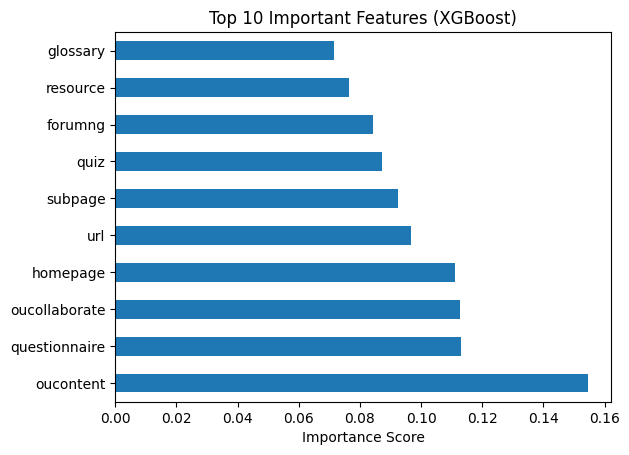

[[ 30  48]
 [  7 151]]
              precision    recall  f1-score   support

           0       0.81      0.38      0.52        78
           1       0.76      0.96      0.85       158

    accuracy                           0.77       236
   macro avg       0.78      0.67      0.68       236
weighted avg       0.78      0.77      0.74       236



['models/feature_columns.pk1']

In [32]:
# Cluster-aware sample weights for XGBoost
sample_weights_xgb = np.ones(len(X_train))

train_meta = data.loc[X_train.index, ["target", "cluster_label"]]

for idx, row in enumerate(train_meta.itertuples()):
    if row.target == 1:
        if row.cluster_label == "Moderate Engagement":
            sample_weights_xgb[idx] = 2.5
        else:  # High Engagement
            sample_weights_xgb[idx] = 1.2
    else:
        sample_weights_xgb[idx] = 1.0


xgb_cluster_aware = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_cluster_aware.fit(
    X_train,
    y_train,
    sample_weight=sample_weights_xgb
)

import pandas as pd
import matplotlib.pyplot as plt

# Feature importance
xgb_importance = pd.Series(
    xgb_cluster_aware.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Top 10 Features:")
print(xgb_importance.head(10))

# Plot
xgb_importance.head(10).plot(kind="barh")
plt.title("Top 10 Important Features (XGBoost)")
plt.xlabel("Importance Score")
plt.show()

y_pred_xgb_cluster = xgb_cluster_aware.predict(X_test)

print(confusion_matrix(y_test, y_pred_xgb_cluster))
print(classification_report(y_test, y_pred_xgb_cluster))

import joblib
joblib.dump(xgb_cluster_aware, "models/xgb_model.pkl")
joblib.dump(list(X_train.columns), "models/feature_columns.pk1")



In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [34]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(rf_importance.head(10))

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Baseline")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

oucontent        0.240842
homepage         0.172198
subpage          0.128369
resource         0.108861
quiz             0.090557
forumng          0.073616
oucollaborate    0.069939
url              0.049386
glossary         0.033376
questionnaire    0.031859
dtype: float64
Random Forest Baseline
[[ 35  43]
 [ 12 146]]
              precision    recall  f1-score   support

           0       0.74      0.45      0.56        78
           1       0.77      0.92      0.84       158

    accuracy                           0.77       236
   macro avg       0.76      0.69      0.70       236
weighted avg       0.76      0.77      0.75       236



In [31]:
import numpy as np

sample_weights_rf = np.ones(len(X_train))

train_meta = data.loc[X_train.index, ["target", "cluster_label"]]

for idx, row in enumerate(train_meta.itertuples()):
    if row.target == 1:
        if row.cluster_label == "Moderate Engagement":
            sample_weights_rf[idx] = 2.5
        else:  # High Engagement
            sample_weights_rf[idx] = 1.2
    else:
        sample_weights_rf[idx] = 1.0


rf_weighted = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_weighted.fit(X_train, y_train, sample_weight=sample_weights_rf)

y_pred_rf_weighted = rf_weighted.predict(X_test)

print("Random Forest (Cluster-aware Weighted)")
print(confusion_matrix(y_test, y_pred_rf_weighted))
print(classification_report(y_test, y_pred_rf_weighted))

Random Forest (Cluster-aware Weighted)
[[ 29  49]
 [ 11 147]]
              precision    recall  f1-score   support

           0       0.72      0.37      0.49        78
           1       0.75      0.93      0.83       158

    accuracy                           0.75       236
   macro avg       0.74      0.65      0.66       236
weighted avg       0.74      0.75      0.72       236

